### 📊 Dataset Overview
This dataset contains 50,000 synthetic mortgage applications with detailed borrower profiles and their calculated maximum viable loan amounts based on real-world underwriting rules. It's designed for regression modeling to predict how much a bank can safely lend to a borrower without risk of default.




### 🎯 Goal of This project

The objective is to predict the maximum loan amount a borrower qualifies for based on their financial and demographic profile. This mirrors what mortgage underwriters do daily — determining loan eligibility amounts while maintaining responsible lending standards.



In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv(r'C:\Users\vikes\Desktop\Mortgage_prediction-ML\notebook\mortgage_loan_dataset.csv')

In [54]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


In [55]:
df.tail()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
49985,Female,57,Yes,Master's,Doctor,38,155977.43,0.03,85565.49,850,2661.55,Rural,5,995780.28
49986,Male,56,Yes,Bachelor's,Banker,29,109407.93,0.05,33965.15,781,1029.63,Suburban,3,659523.17
49987,Female,55,No,Bachelor's,Banker,33,110671.03,0.09,62713.63,666,1511.39,Suburban,1,354407.87
49988,Female,67,Yes,Bachelor's,Doctor,42,125888.77,0.04,28860.76,810,1954.98,Suburban,5,713931.03
49989,Female,30,Yes,Master's,Software Engineer,2,109885.05,0.03,56409.64,800,1742.82,Rural,3,688714.37


###  Data Checks to perform
Check Missing values

Check Duplicates

Check data type

Check the number of unique values of each column

Check statistics of data set

Check various categories present in the different categorical column


In [56]:
df.isna().sum()

Gender                         0
Age                            0
Married                        0
Education                      0
Job                            0
Employment Years               0
Annual Income (USD)            0
Interest Rate                  0
Down Payment (USD)             0
Credit Score                   0
Existing Monthly Debt (USD)    0
Area                           0
Loans Repaid                   0
Max Loan Amount (USD)          0
dtype: int64

In [57]:
df.duplicated().sum()

0

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       49990 non-null  object 
 1   Age                          49990 non-null  int64  
 2   Married                      49990 non-null  object 
 3   Education                    49990 non-null  object 
 4   Job                          49990 non-null  object 
 5   Employment Years             49990 non-null  int64  
 6   Annual Income (USD)          49990 non-null  float64
 7   Interest Rate                49990 non-null  float64
 8   Down Payment (USD)           49990 non-null  float64
 9   Credit Score                 49990 non-null  int64  
 10  Existing Monthly Debt (USD)  49990 non-null  float64
 11  Area                         49990 non-null  object 
 12  Loans Repaid                 49990 non-null  int64  
 13  Max Loan Amount 

In [59]:
df.nunique()

Gender                             2
Age                               59
Married                            2
Education                          4
Job                               12
Employment Years                  51
Annual Income (USD)            49660
Interest Rate                     10
Down Payment (USD)             48413
Credit Score                     271
Existing Monthly Debt (USD)    45521
Area                               3
Loans Repaid                      25
Max Loan Amount (USD)          49976
dtype: int64

In [60]:
df.describe()

,Age,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Max Loan Amount (USD)
count,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,4.999000e+04
mean,57.046609,32.068234,120323.418437,0.050957,64296.936887,760.373195,1656.598654,5.825545,6.634191e+05
std,16.947352,15.171406,36965.115132,0.020815,39594.864102,63.385441,751.032649,3.431778,3.126811e+05
min,28.000000,0.000000,25000.000000,0.030000,5000.000000,580.000000,0.000000,0.000000,2.614254e+04
25%,42.000000,19.000000,95011.170000,0.030000,34152.762500,717.000000,1099.917500,3.000000,4.254228e+05
50%,57.000000,34.000000,119978.225000,0.050000,59097.870000,764.000000,1564.655000,5.000000,6.232435e+05
75%,72.000000,48.000000,145455.785000,0.060000,87905.060000,811.000000,2140.255000,8.000000,8.641049e+05
max,86.000000,50.000000,274740.320000,0.120000,250000.000000,850.000000,5000.000000,24.000000,2.270836e+06


## Exploring Data

In [61]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


In [62]:
categorical_columns = df.select_dtypes(include='object').columns

In [63]:
categorical_columns

Index(['Gender', 'Married', 'Education', 'Job', 'Area'], dtype='object')

In [64]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Gender
['Male' 'Female']

Married
['Yes' 'No']

Education
['PhD' 'High School' "Bachelor's" "Master's"]

Job
['Software Engineer' 'Freelancer' 'Nurse' 'Business Owner' 'Accountant'
 'Banker' 'Teacher' 'Retired' 'Lawyer' 'Doctor' 'Engineer' 'Sales Manager']

Area
['Urban' 'Suburban' 'Rural']


## Analyze the Target Variable First

In [65]:
target = "Max Loan Amount (USD)"

In [66]:
round(df[target].describe(),2)

count      49990.00
mean      663419.15
std       312681.14
min        26142.54
25%       425422.80
50%       623243.47
75%       864104.89
max      2270835.80
Name: Max Loan Amount (USD), dtype: float64

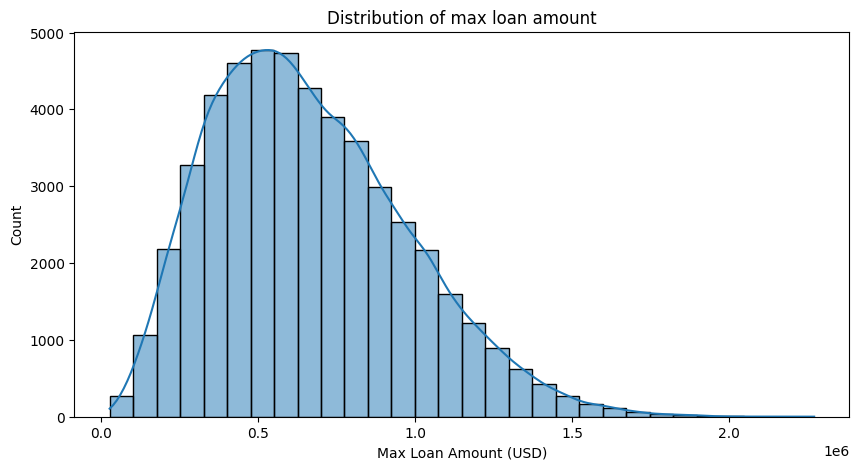

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(df[target],bins=30,kde=True)
plt.title("Distribution of max loan amount")
plt.show()

In [68]:
df[target].skew()

0.594434636478105

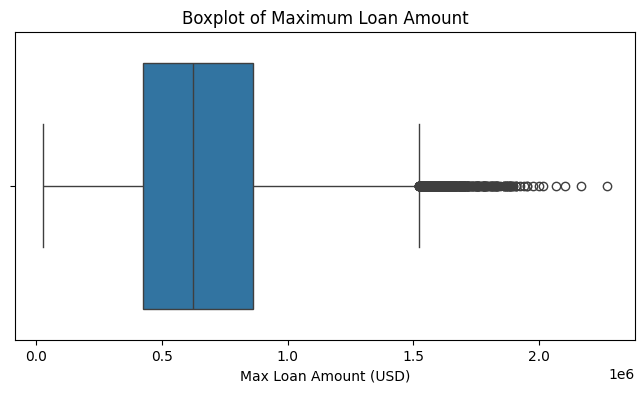

In [69]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df[target])

plt.title("Boxplot of Maximum Loan Amount")
plt.show()

## Numerical Features

In [70]:
numerical_columns = df.select_dtypes(exclude="object").columns

numerical_columns

Index(['Age', 'Employment Years', 'Annual Income (USD)', 'Interest Rate',
       'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)',
       'Loans Repaid', 'Max Loan Amount (USD)'],
      dtype='object')

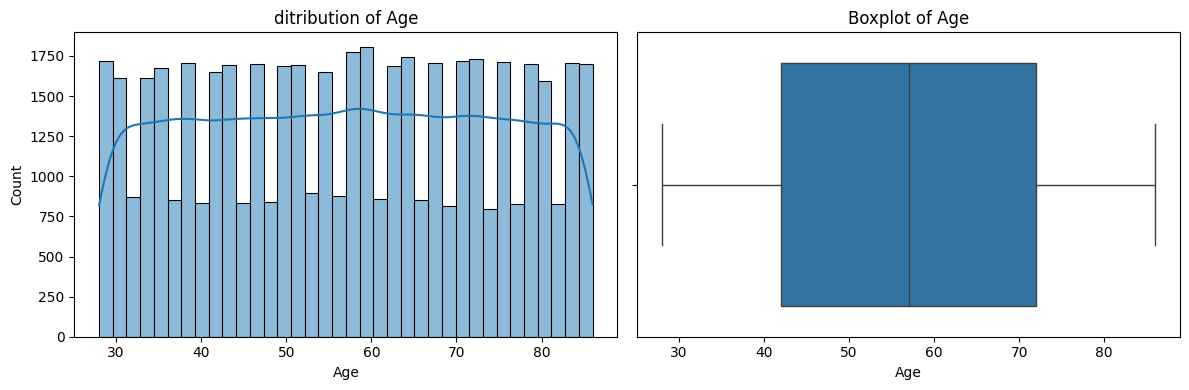

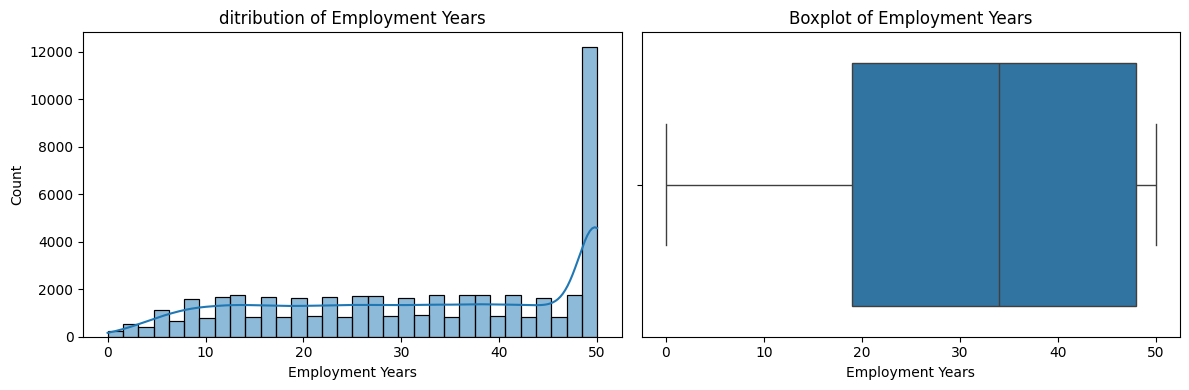

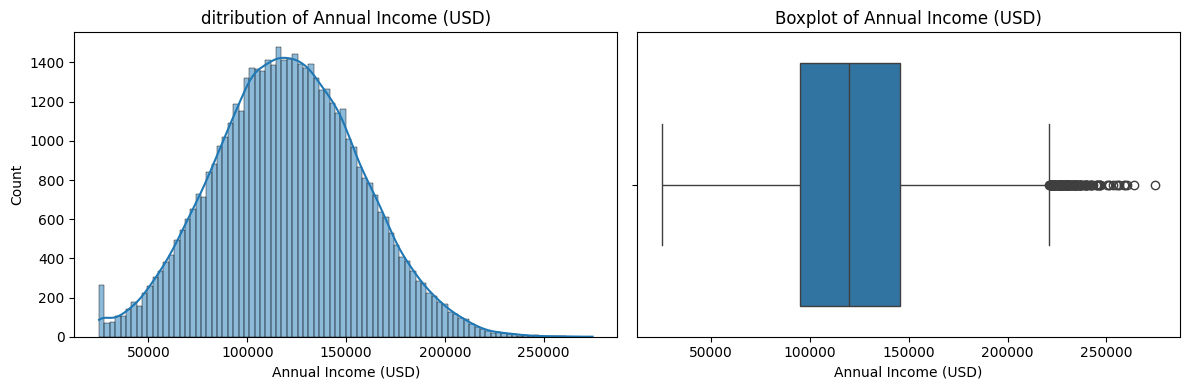

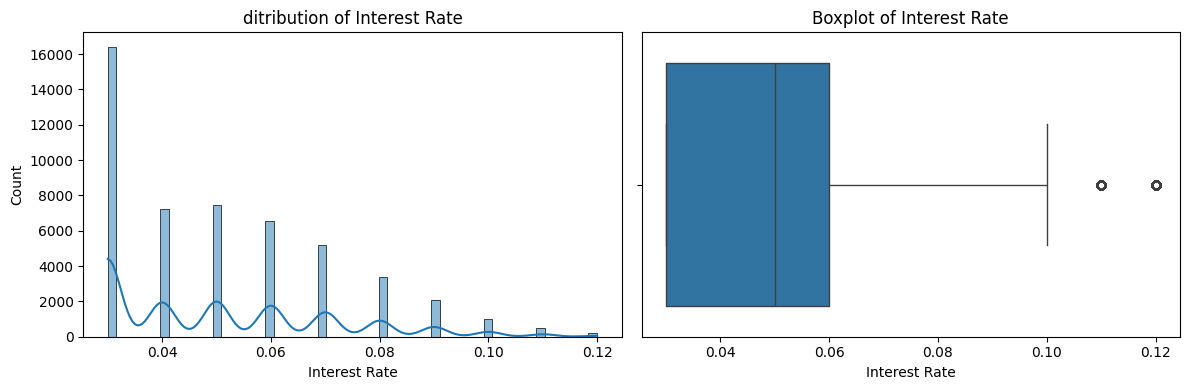

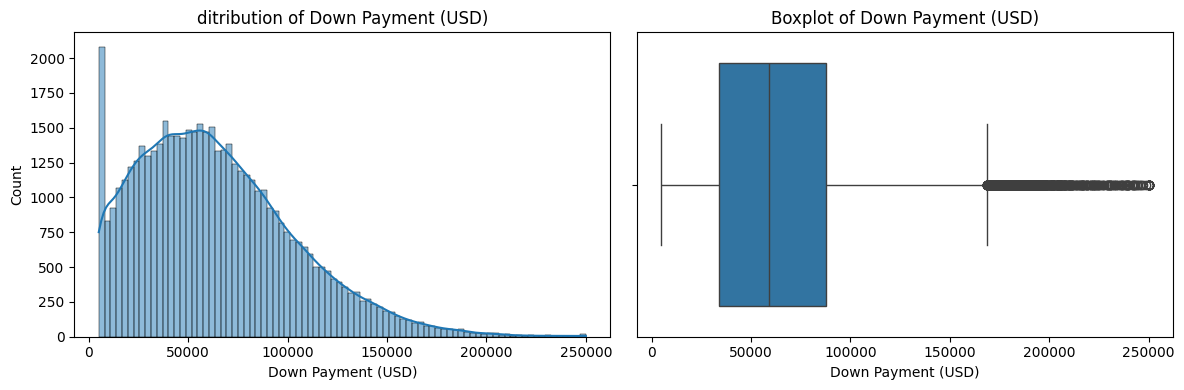

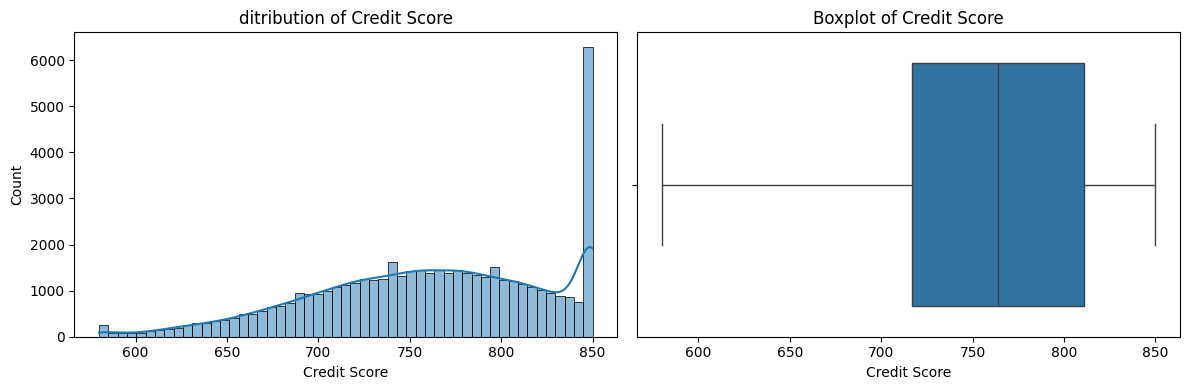

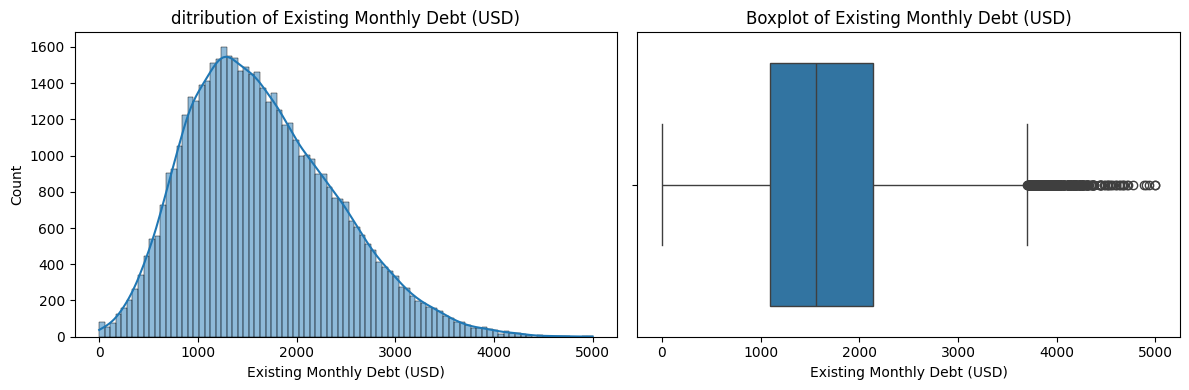

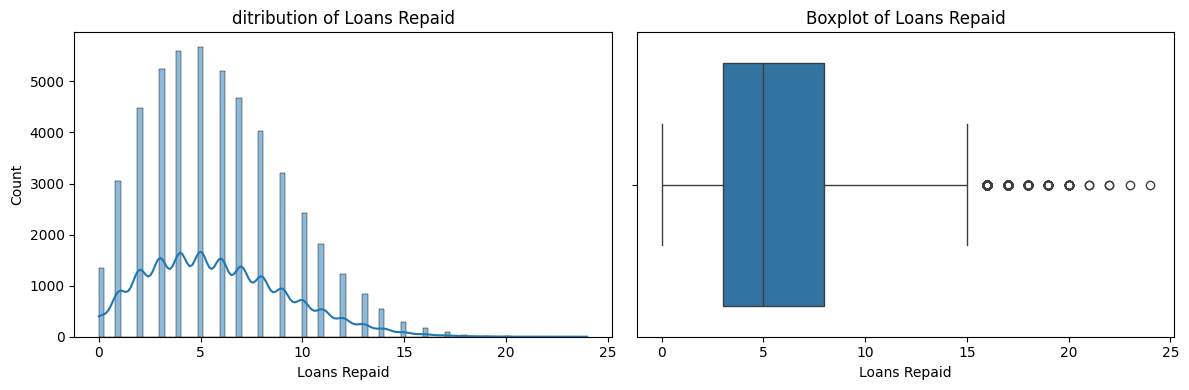

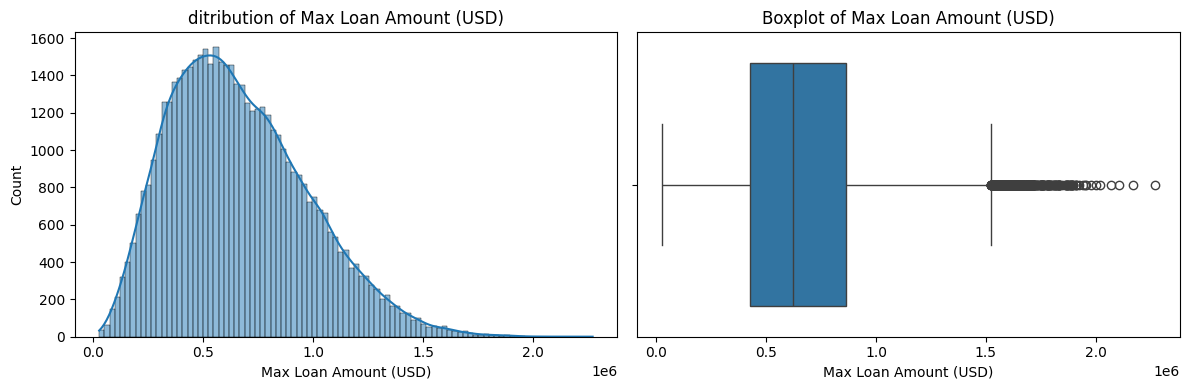

In [71]:
for column in numerical_columns:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[column],kde=True)
    plt.title(f"ditribution of {column}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

In [72]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_df.corr()

corr_matrix

,Age,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Max Loan Amount (USD)
Age,1.000000,0.974174,0.323471,-0.365689,0.162189,0.388481,0.223824,0.689338,0.405882
Employment Years,0.974174,1.000000,0.332643,-0.361071,0.166601,0.381377,0.230616,0.672619,0.406553
Annual Income (USD),0.323471,0.332643,1.000000,-0.216614,0.494139,0.230020,0.680145,0.240069,0.758454
Interest Rate,-0.365689,-0.361071,-0.216614,1.000000,-0.107657,-0.954315,-0.149606,-0.404812,-0.649185
Down Payment (USD),0.162189,0.166601,0.494139,-0.107657,1.000000,0.113835,0.333611,0.118728,0.471863
Credit Score,0.388481,0.381377,0.230020,-0.954315,0.113835,1.000000,0.160581,0.428097,0.664412
Existing Monthly Debt (USD),0.223824,0.230616,0.680145,-0.149606,0.333611,0.160581,1.000000,0.166618,0.275322
Loans Repaid,0.689338,0.672619,0.240069,-0.404812,0.118728,0.428097,0.166618,1.000000,0.372657
Max Loan Amount (USD),0.405882,0.406553,0.758454,-0.649185,0.471863,0.664412,0.275322,0.372657,1.000000


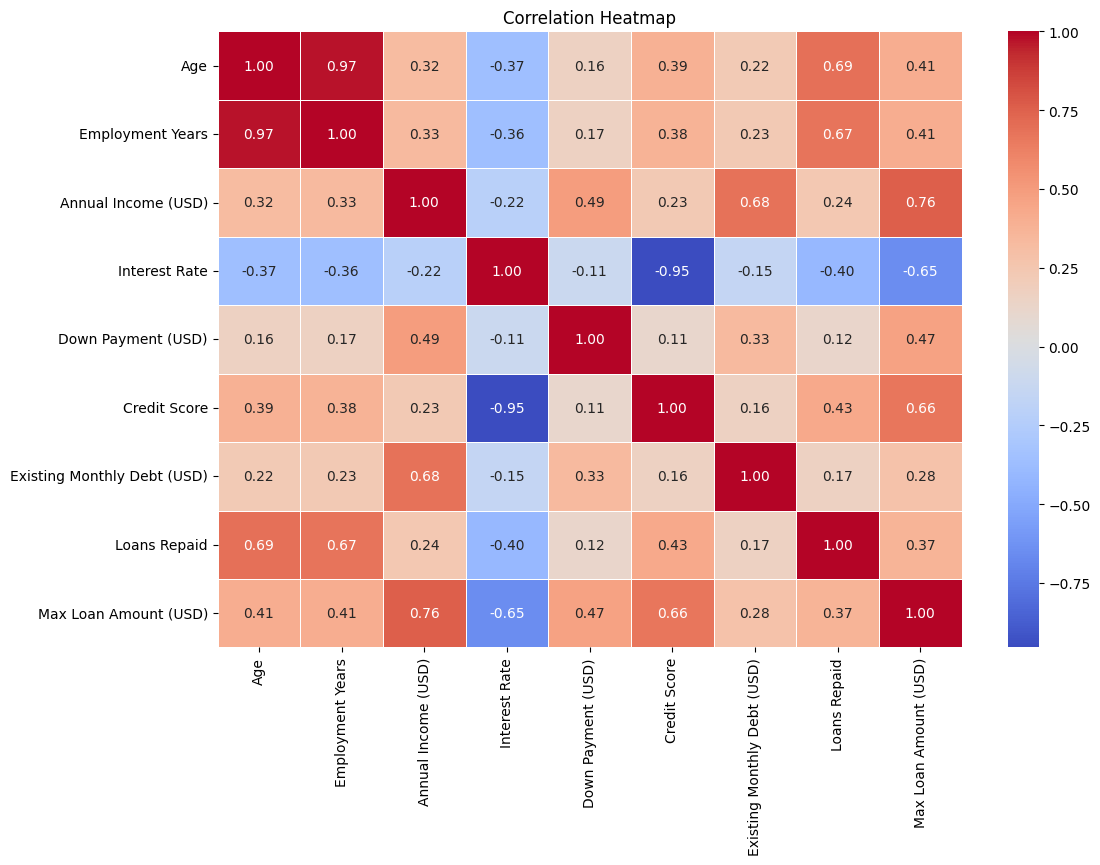

In [73]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [74]:
target = "Max Loan Amount (USD)"

corr_with_target = (
    corr_matrix[target]
    .sort_values(ascending=False)
)

corr_with_target

Max Loan Amount (USD)          1.000000
Annual Income (USD)            0.758454
Credit Score                   0.664412
Down Payment (USD)             0.471863
Employment Years               0.406553
Age                            0.405882
Loans Repaid                   0.372657
Existing Monthly Debt (USD)    0.275322
Interest Rate                 -0.649185
Name: Max Loan Amount (USD), dtype: float64

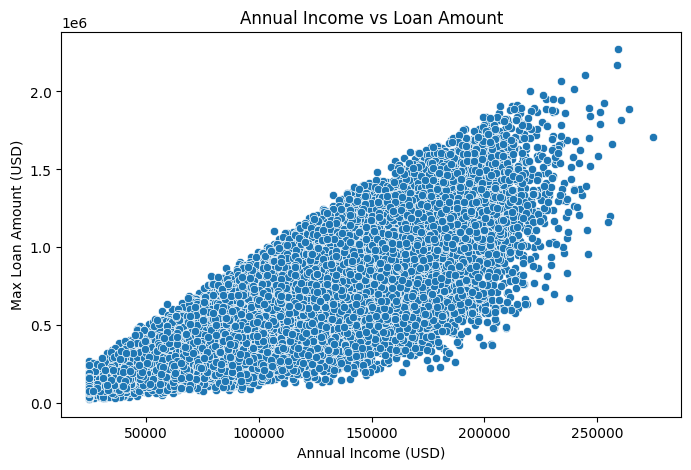

In [75]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Annual Income (USD)"],
    y=df[target]
)

plt.title("Annual Income vs Loan Amount")
plt.show()

## Bivariate analysis

In [76]:
df.groupby("Education")[target].agg(["mean", "median", "count"])

,mean,median,count
Education,,,
Bachelor's,629909.393599,590615.74,19920
High School,540974.948118,495140.75,7573
Master's,705808.442038,668168.93,14969
PhD,790977.446825,769189.30,7528


In [77]:
df.groupby("Job")[target].agg(["mean", "median", "count"])

,mean,median,count
Job,,,
Accountant,573633.362814,539727.510,4193
Banker,686367.611849,649431.390,4132
Business Owner,807226.138980,780884.670,4235
Doctor,818661.694289,791988.765,4180
Engineer,575127.113283,541863.190,4094
Freelancer,574852.590747,537159.130,4217
Lawyer,809328.989772,782799.260,4170
Nurse,573395.794486,543503.270,4215
Retired,579564.430170,539993.780,4177


In [78]:
df.groupby("Area")[target].agg(["mean", "median", "count"])

,mean,median,count
Area,,,
Rural,665522.865942,623743.755,7550
Suburban,662391.130192,625021.560,14974
Urban,663401.324175,622747.145,27466


## Multivariate Analysis

In [79]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


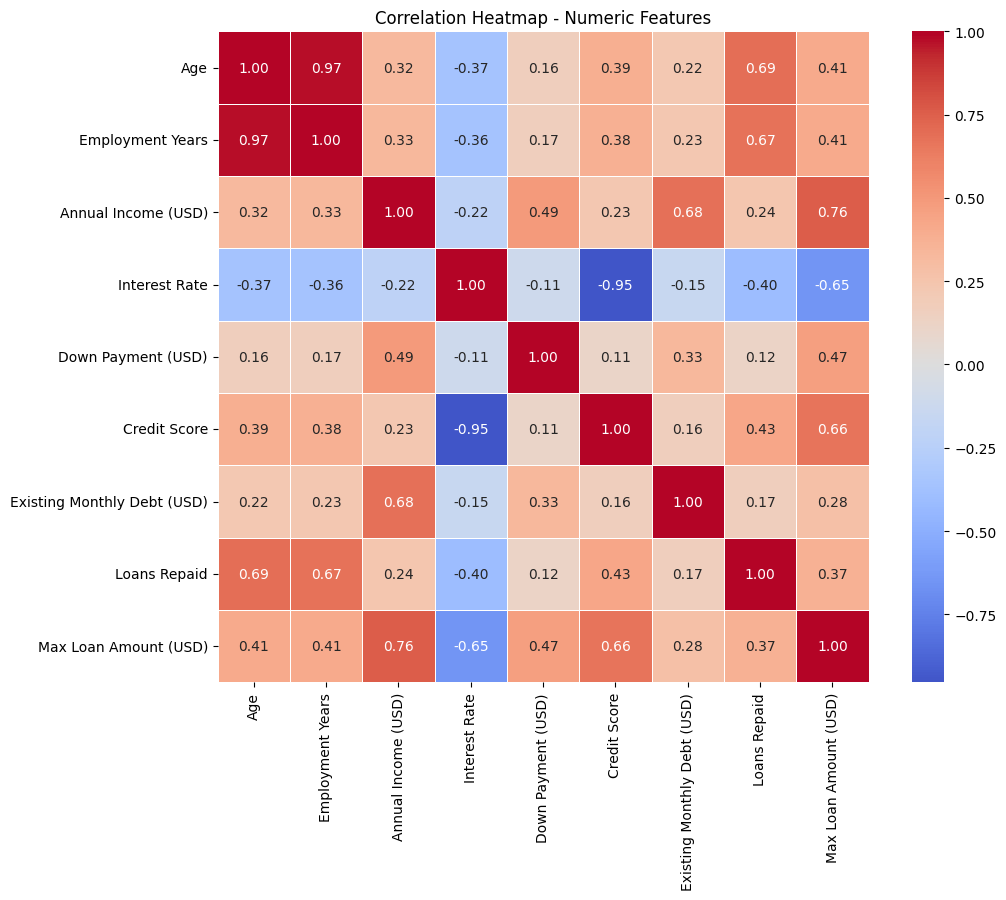

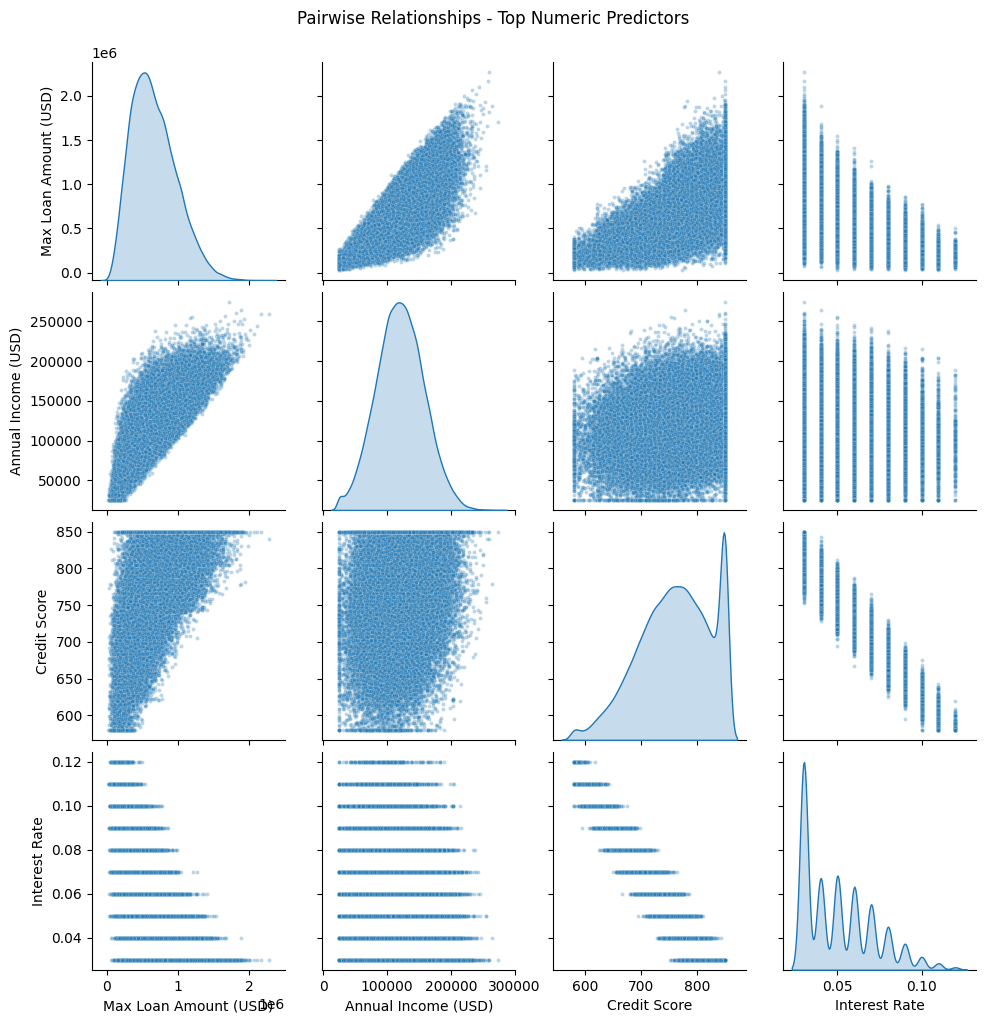

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

numeric_cols = ['Age', 'Employment Years', 'Annual Income (USD)', 'Interest Rate',
                 'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)',
                 'Loans Repaid', 'Max Loan Amount (USD)']

# 1a. Correlation heatmap
plt.figure(figsize=(11, 9))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

# 1b. Pairplot for the strongest features + target
key_features = ['Max Loan Amount (USD)', 'Annual Income (USD)', 'Credit Score', 'Interest Rate']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.3, 's': 8})
plt.suptitle('Pairwise Relationships - Top Numeric Predictors', y=1.02)
plt.show()

In This data: Age and Employment Years correlate at 0.97. That means if I know someone's age, I can guess their employment years almost perfectly. They're carrying almost the same signal into the model twice.

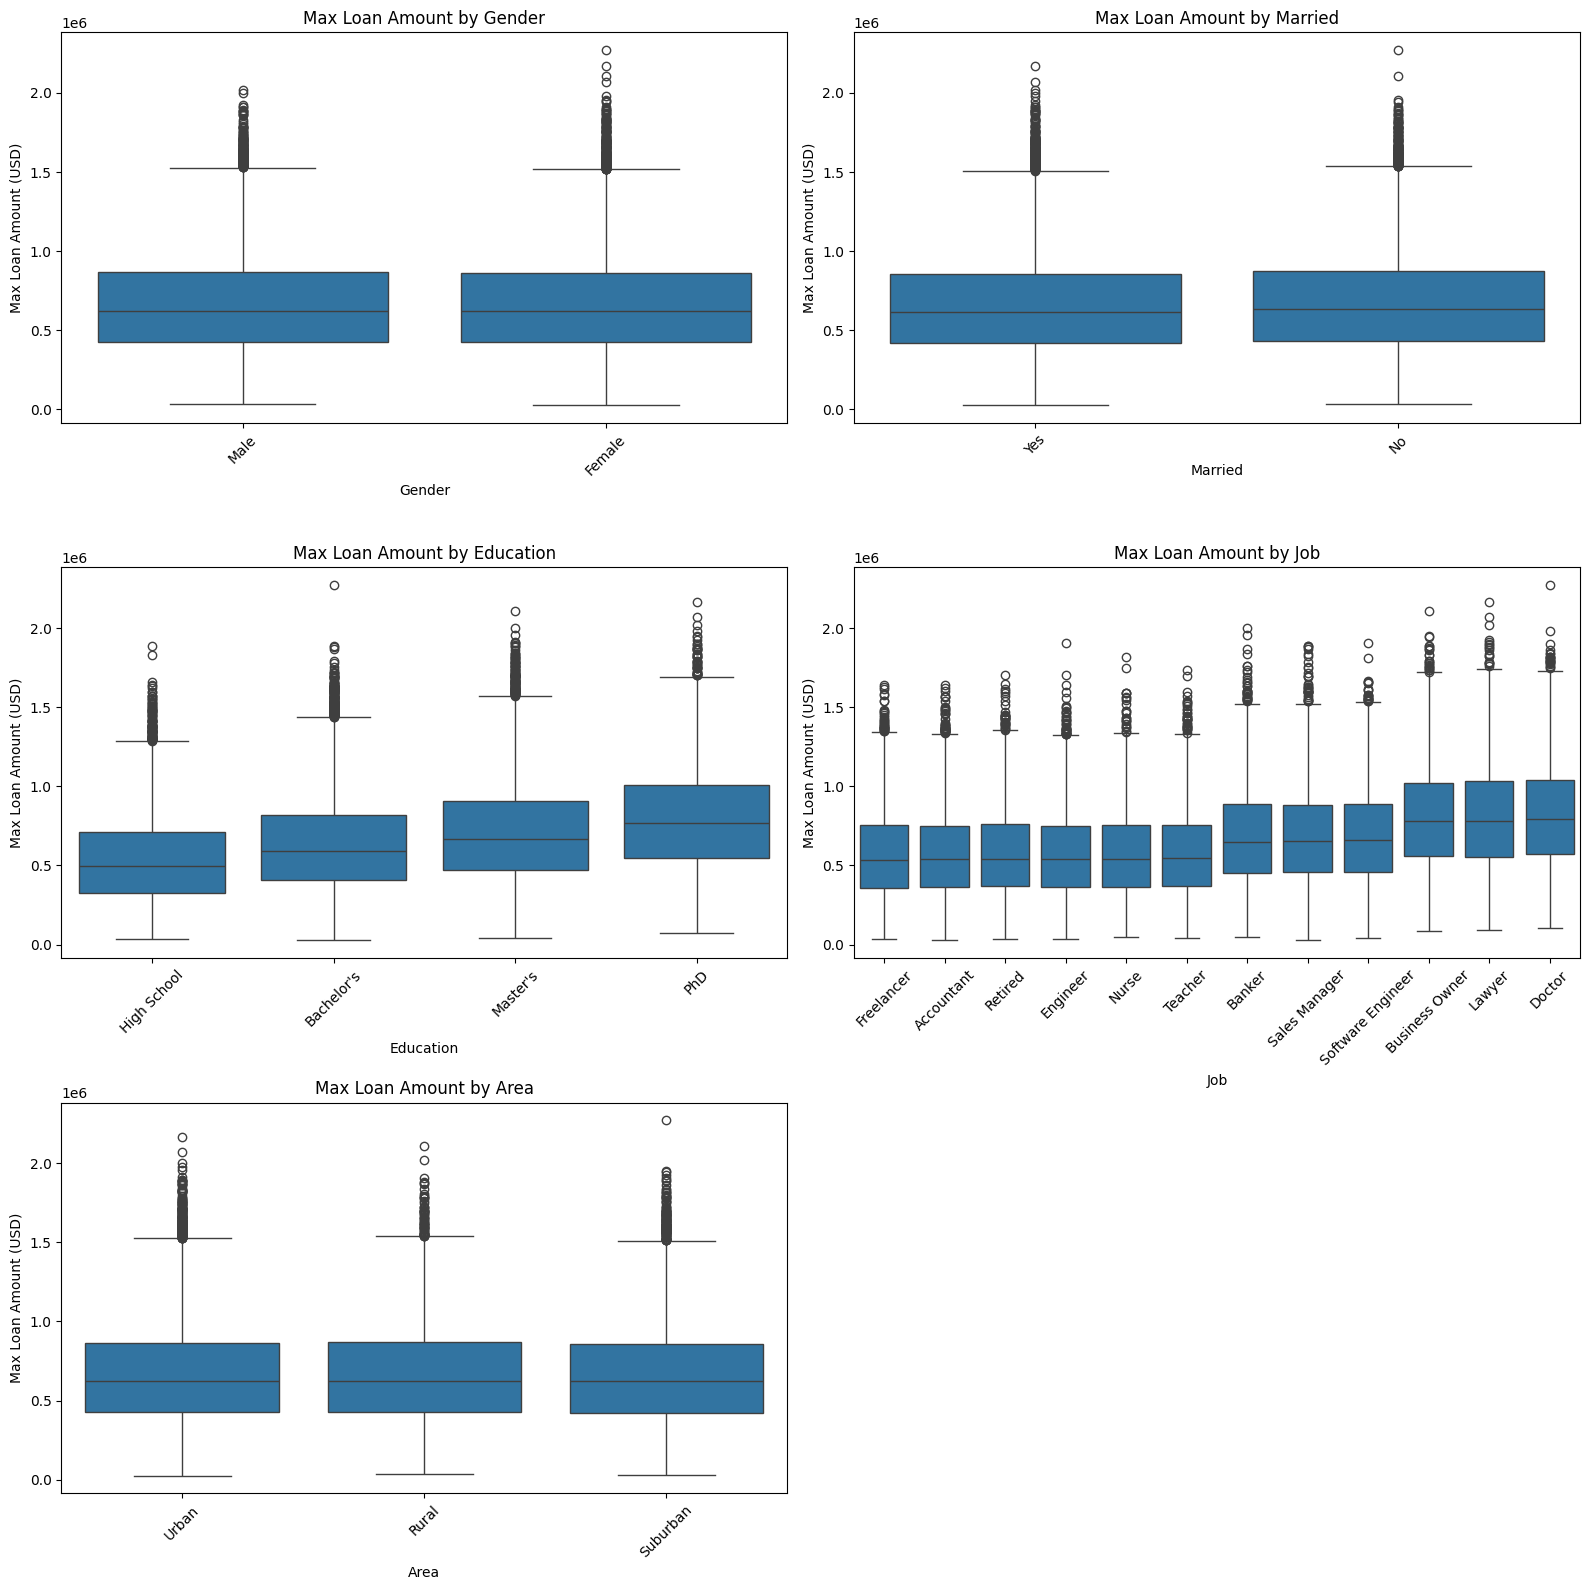

In [81]:
categorical_cols = ['Gender', 'Married', 'Education', 'Job', 'Area']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df.groupby(col)['Max Loan Amount (USD)'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='Max Loan Amount (USD)', order=order, ax=axes[i])
    axes[i].set_title(f'Max Loan Amount by {col}')
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[-1])  # remove unused subplot
plt.tight_layout()
plt.show()

In [82]:
df_clean=df

In [83]:
df_fe = df_clean.copy()

In [84]:
df_fe = df_clean.copy()

# 1. Debt-to-Income Ratio
df_fe['DTI'] = (df_fe['Existing Monthly Debt (USD)'] * 12) / df_fe['Annual Income (USD)']

# 2. Career Ratio — replaces Age + Employment Years collinearity
df_fe['Career_Ratio'] = df_fe['Employment Years'] / df_fe['Age']

# 3. Drop Employment Years (redundant with Age once Career_Ratio exists)
df_fe = df_fe.drop(columns=['Employment Years'])

# 4. Drop no-signal categoricals
df_fe = df_fe.drop(columns=['Gender', 'Area'])

# 5. Ordinal encode Education
education_order = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df_fe['Education_Encoded'] = df_fe['Education'].map(education_order)
df_fe = df_fe.drop(columns=['Education'])

# 6. Binary encode Married
df_fe['Married_Encoded'] = df_fe['Married'].map({'Yes': 1, 'No': 0})
df_fe = df_fe.drop(columns=['Married'])

# 7. One-hot encode Job
df_fe = pd.get_dummies(df_fe, columns=['Job'], prefix='Job', drop_first=True)

# 8. Log-transform target
df_fe['Log_Max_Loan'] = np.log1p(df_fe['Max Loan Amount (USD)'])

print(df_fe.shape)
df_fe.head()

(49990, 24)


,Age,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Max Loan Amount (USD),DTI,Career_Ratio,...,Job_Doctor,Job_Engineer,Job_Freelancer,Job_Lawyer,Job_Nurse,Job_Retired,Job_Sales Manager,Job_Software Engineer,Job_Teacher,Log_Max_Loan
0,36,134183.86,0.08,101706.78,682,2045.80,3,498842.67,0.182955,0.361111,...,False,False,False,False,False,False,False,True,False,13.120048
1,63,68884.95,0.03,46324.29,823,804.73,10,536232.53,0.140187,0.587302,...,False,False,True,False,False,False,False,False,False,13.192325
2,33,76396.27,0.03,13045.79,813,1050.54,0,518884.47,0.165014,0.333333,...,False,False,False,False,True,False,False,False,False,13.159438
3,51,115968.80,0.05,60388.40,752,904.08,2,757940.14,0.093551,0.568627,...,False,False,False,False,False,False,False,False,False,13.538361
4,53,99977.38,0.06,54838.14,728,2285.76,1,283110.21,0.274353,0.509434,...,False,False,False,False,True,False,False,False,False,12.553595


In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

numeric_for_vif = ['Age', 'Career_Ratio', 'Annual Income (USD)', 'Interest Rate',
                    'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)',
                    'Loans Repaid', 'DTI']

X_vif = add_constant(df_fe[numeric_for_vif].dropna())

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False))

                       Feature        VIF
7  Existing Monthly Debt (USD)  17.337450
6                 Credit Score  11.545612
4                Interest Rate  11.222325
3          Annual Income (USD)   9.447191
9                          DTI   9.317260
1                          Age   3.905663
2                 Career_Ratio   2.964592
8                 Loans Repaid   2.022127
5           Down Payment (USD)   1.323109


### Ordinal vs One-Hot Encoding

In [86]:
education_order = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df['Education_Encoded'] = df['Education'].map(education_order)

In [87]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD),Education_Encoded
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67,3
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53,0
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47,3
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14,1
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21,1


In [88]:
df['Job'].nunique()

12

In [89]:
df = pd.get_dummies(df, columns=['Job'], prefix='Job', drop_first=True)

In [90]:
df["Debt_to_Income_Ratio"] = (
    df["Existing Monthly Debt (USD)"] /
    df["Annual Income (USD)"]
)

In [91]:
# Create Down Payment Ratio
df["Down_Payment_Ratio"] = (
    df["Down Payment (USD)"] /
    df["Annual Income (USD)"]
)

In [92]:
df["Experience_Age_Ratio"] = (
    df["Employment Years"] /
    df["Age"]
)

In [93]:
df["Income_per_Employment_Year"] = np.where(
    df["Employment Years"] == 0,
    0,
    df["Annual Income (USD)"] /
    df["Employment Years"]
)

In [94]:
def credit_category(score):
    if score < 580:
        return "Poor"
    elif score < 670:
        return "Fair"
    elif score < 740:
        return "Good"
    elif score < 800:
        return "Very Good"
    else:
        return "Excellent"

df["Credit_Category"] = df["Credit Score"].apply(credit_category)

In [95]:
df["Credit_Category"].value_counts()

Credit_Category
Very Good    16489
Excellent    15367
Good         13689
Fair          4445
Name: count, dtype: int64

In [96]:
df.head()

,Gender,Age,Married,Education,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),...,Job_Nurse,Job_Retired,Job_Sales Manager,Job_Software Engineer,Job_Teacher,Debt_to_Income_Ratio,Down_Payment_Ratio,Experience_Age_Ratio,Income_per_Employment_Year,Credit_Category
0,Male,36,Yes,PhD,13,134183.86,0.08,101706.78,682,2045.80,...,False,False,False,True,False,0.015246,0.757966,0.361111,10321.835385,Good
1,Female,63,No,High School,37,68884.95,0.03,46324.29,823,804.73,...,False,False,False,False,False,0.011682,0.672488,0.587302,1861.755405,Excellent
2,Female,33,Yes,PhD,11,76396.27,0.03,13045.79,813,1050.54,...,True,False,False,False,False,0.013751,0.170765,0.333333,6945.115455,Excellent
3,Female,51,Yes,Bachelor's,29,115968.80,0.05,60388.40,752,904.08,...,False,False,False,False,False,0.007796,0.520730,0.568627,3998.924138,Very Good
4,Male,53,Yes,Bachelor's,27,99977.38,0.06,54838.14,728,2285.76,...,True,False,False,False,False,0.022863,0.548505,0.509434,3702.865926,Good


In [97]:
new_features = [
    "Debt_to_Income_Ratio",
    "Down_Payment_Ratio",
    "Experience_Age_Ratio",
    "Income_per_Employment_Year",
    "Credit_Category"
]

df[new_features].head()

,Debt_to_Income_Ratio,Down_Payment_Ratio,Experience_Age_Ratio,Income_per_Employment_Year,Credit_Category
0,0.015246,0.757966,0.361111,10321.835385,Good
1,0.011682,0.672488,0.587302,1861.755405,Excellent
2,0.013751,0.170765,0.333333,6945.115455,Excellent
3,0.007796,0.520730,0.568627,3998.924138,Very Good
4,0.022863,0.548505,0.509434,3702.865926,Good


In [108]:
df.to_csv("mortgage_processed.csv", index=False)